In [1]:
import matplotlib.pyplot as plt
import glob
import numpy as np
import pandas as pd
import math
import seaborn as sns

import sys, os, platform, glob, zipfile, math, shutil, random, gc, json, re, pathlib
from scipy.optimize import curve_fit
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score

from sklearn.model_selection import train_test_split

from sklearn.neural_network import MLPClassifier
from sklearn.neural_network import MLPRegressor
from sklearn.datasets import make_regression

from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, confusion_matrix, roc_curve, precision_recall_curve
from sklearn.utils.class_weight import compute_class_weight
from sklearn.svm import SVC

from sklearn.datasets import make_classification
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import LearningCurveDisplay, ShuffleSplit

In [3]:
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
file_path = '/content/drive/MyDrive/ml files/updatedmuon.csv'

df = pd.read_csv(file_path)

print(df)

       collisionID  trackID     mcID      eta        pt          p      phi  \
0              111       -1    88367 -3.16496  0.243115   2.884550 -2.59080   
1              111        0    88367  2.72339  0.115458   0.883115  6.49523   
2              125       -1   102667 -3.41393  0.858880  13.062400  2.80120   
3              125        2   102667 -3.43907  0.996715  15.543900  2.77976   
4              168        5   133004 -2.81062  0.592036   4.937700 -2.29163   
...            ...      ...      ...      ...       ...        ...      ...   
88156         1694    11870  2165162 -2.53649  1.267230   8.056050 -1.19439   
88157         1694    11870  2165162 -2.26606  2.343080  11.416700 -2.10517   
88158         1694    11870  2165162 -2.20876  1.795700   8.273080 -1.53141   
88159         1694    11870  2165162 -2.49586  1.298260   7.928870 -1.22032   
88160         1694       -2  2168601 -2.99374  0.450407   4.506400 -1.57832   

       motherPDG  nClusters  trackType      pDca   

In [6]:
filter_df = df[(df['chi2'] <= 10)]
track_df = df[(df['trackType'] == 3)]
cut_df = track_df[(track_df['p'] > 4) & (track_df['eta'] >= -4) & (track_df['eta'] <= -2.5) & (track_df['pt'] > 0.5)] #consists of the chi2, track type & momentum cuts needed

In [7]:
cut_df.to_csv('cutsapplied(nochi2).csv', index=False)
cut_df.to_csv('/content/drive/MyDrive/ml files/cutsapplied.csv', index=False)

In [8]:
signalD = [abs(411), abs(421), abs(431), abs(4122), abs(4232), abs(4132)]
signalB = [abs(521), abs(511), abs(531), abs(5232), abs(5132), abs(5122)]
signalPDG = [abs(411), abs(421), abs(431), abs(4122), abs(4232), abs(4132), abs(521), abs(511), abs(531), abs(5232), abs(5132), abs(5122)]


In [9]:
focus_signal = "D"

label = []

for index, row in cut_df.iterrows():
    pdg = abs(row['motherPDG'])

    if focus_signal == "B":
        if pdg in signalB:
            label.append("s")   # B meson signal
        elif pdg in signalD:
            label.append("x")   # excluded (not background, not signal)
        else:
            label.append("b")   # background

    elif focus_signal == "D":
        if pdg in signalD:
            label.append("s")   # D meson signal
        elif pdg in signalB:
            label.append("x")   # excluded
        else:
            label.append("b")   # background

cut_df['label'] = label

/tmp/ipython-input-3433308258.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cut_df['label'] = label


In [10]:
cut_df

,collisionID,trackID,mcID,eta,pt,p,phi,motherPDG,nClusters,trackType,pDca,chi2,chi2MatchMCHMID,rabs,isPrompt,tracktime,sign,label
2,125,-1,102667,-3.41393,0.858880,13.06240,2.801200,321,12,3,44.9307,0.144531,0.554688,31.1311,1,286.939819,1,b
6,218,-1,171002,-2.93607,0.560673,5.29689,1.075610,321,10,3,140.5290,0.210938,1.062500,31.8958,1,736.044556,-1,b
8,252,-1,197209,-3.73895,0.510914,10.74910,0.096842,321,10,3,51.1675,0.232422,1.304690,26.5259,1,910.683838,-1,b
20,719,-5,540836,-3.46161,0.574716,9.16664,-0.345634,321,12,3,134.2360,0.092773,0.703125,18.2902,1,611.293945,1,b
34,877,-5,657418,-2.95560,0.560175,5.39596,2.508450,211,10,3,105.3500,0.173828,1.203120,36.8680,0,12.463362,-1,b
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88090,1684,-2,2155308,-2.86598,0.821995,7.24307,-1.208640,411,10,3,16.0551,0.120605,0.894531,56.2943,1,37.463413,1,s
88091,1684,-2,2155794,-3.73386,0.546972,11.44930,2.459840,421,9,3,40.6495,0.129883,0.511719,26.3077,1,910.650940,-1,s
88119,1688,-2,2159871,-3.51072,0.830579,13.91310,-1.892480,431,7,3,30.4072,0.375000,0.585938,29.1006,1,486.548035,1,s
88125,1689,-2,2161464,-3.29699,0.758238,10.26200,1.238660,431,14,3,59.5527,0.102539,1.593750,33.4272,1,511.483124,1,s


In [11]:
cut_df = cut_df[cut_df['label'] != 'x']

In [12]:
cut_df

,collisionID,trackID,mcID,eta,pt,p,phi,motherPDG,nClusters,trackType,pDca,chi2,chi2MatchMCHMID,rabs,isPrompt,tracktime,sign,label
2,125,-1,102667,-3.41393,0.858880,13.06240,2.801200,321,12,3,44.9307,0.144531,0.554688,31.1311,1,286.939819,1,b
6,218,-1,171002,-2.93607,0.560673,5.29689,1.075610,321,10,3,140.5290,0.210938,1.062500,31.8958,1,736.044556,-1,b
8,252,-1,197209,-3.73895,0.510914,10.74910,0.096842,321,10,3,51.1675,0.232422,1.304690,26.5259,1,910.683838,-1,b
20,719,-5,540836,-3.46161,0.574716,9.16664,-0.345634,321,12,3,134.2360,0.092773,0.703125,18.2902,1,611.293945,1,b
34,877,-5,657418,-2.95560,0.560175,5.39596,2.508450,211,10,3,105.3500,0.173828,1.203120,36.8680,0,12.463362,-1,b
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88090,1684,-2,2155308,-2.86598,0.821995,7.24307,-1.208640,411,10,3,16.0551,0.120605,0.894531,56.2943,1,37.463413,1,s
88091,1684,-2,2155794,-3.73386,0.546972,11.44930,2.459840,421,9,3,40.6495,0.129883,0.511719,26.3077,1,910.650940,-1,s
88119,1688,-2,2159871,-3.51072,0.830579,13.91310,-1.892480,431,7,3,30.4072,0.375000,0.585938,29.1006,1,486.548035,1,s
88125,1689,-2,2161464,-3.29699,0.758238,10.26200,1.238660,431,14,3,59.5527,0.102539,1.593750,33.4272,1,511.483124,1,s


In [13]:
l = cut_df['label']
l.value_counts()

,count
label,
b,5485
s,2923


In [14]:
print(cut_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 8408 entries, 2 to 88143
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   collisionID      8408 non-null   int64  
 1   trackID          8408 non-null   int64  
 2   mcID             8408 non-null   int64  
 3   eta              8408 non-null   float64
 4   pt               8408 non-null   float64
 5   p                8408 non-null   float64
 6   phi              8408 non-null   float64
 7   motherPDG        8408 non-null   int64  
 8   nClusters        8408 non-null   int64  
 9   trackType        8408 non-null   int64  
 10  pDca             8408 non-null   float64
 11  chi2             8408 non-null   float64
 12  chi2MatchMCHMID  8408 non-null   float64
 13  rabs             8408 non-null   float64
 14  isPrompt         8408 non-null   int64  
 15  tracktime        8408 non-null   float64
 16  sign             8408 non-null   int64  
 17  label            8

In [15]:
cut_df['y'] = (cut_df["label"] == "s").astype(int)

y = cut_df['y'].to_numpy()

/tmp/ipython-input-3848919311.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cut_df['y'] = (cut_df["label"] == "s").astype(int)


In [16]:
weight = compute_class_weight(class_weight="balanced", classes=np.unique(y), y=y)
print(weight)

[0.76645397 1.43824837]


In [17]:
cut_df['w'] = np.where(cut_df['y'] == 1, weight[1], weight[0])
w = cut_df['w']

/tmp/ipython-input-4139032214.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cut_df['w'] = np.where(cut_df['y'] == 1, weight[1], weight[0])


In [18]:
w.value_counts()

,count
w,
0.766454,5485
1.438248,2923


In [19]:
cut_df

,collisionID,trackID,mcID,eta,pt,p,phi,motherPDG,nClusters,trackType,pDca,chi2,chi2MatchMCHMID,rabs,isPrompt,tracktime,sign,label,y,w
2,125,-1,102667,-3.41393,0.858880,13.06240,2.801200,321,12,3,44.9307,0.144531,0.554688,31.1311,1,286.939819,1,b,0,0.766454
6,218,-1,171002,-2.93607,0.560673,5.29689,1.075610,321,10,3,140.5290,0.210938,1.062500,31.8958,1,736.044556,-1,b,0,0.766454
8,252,-1,197209,-3.73895,0.510914,10.74910,0.096842,321,10,3,51.1675,0.232422,1.304690,26.5259,1,910.683838,-1,b,0,0.766454
20,719,-5,540836,-3.46161,0.574716,9.16664,-0.345634,321,12,3,134.2360,0.092773,0.703125,18.2902,1,611.293945,1,b,0,0.766454
34,877,-5,657418,-2.95560,0.560175,5.39596,2.508450,211,10,3,105.3500,0.173828,1.203120,36.8680,0,12.463362,-1,b,0,0.766454
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88090,1684,-2,2155308,-2.86598,0.821995,7.24307,-1.208640,411,10,3,16.0551,0.120605,0.894531,56.2943,1,37.463413,1,s,1,1.438248
88091,1684,-2,2155794,-3.73386,0.546972,11.44930,2.459840,421,9,3,40.6495,0.129883,0.511719,26.3077,1,910.650940,-1,s,1,1.438248
88119,1688,-2,2159871,-3.51072,0.830579,13.91310,-1.892480,431,7,3,30.4072,0.375000,0.585938,29.1006,1,486.548035,1,s,1,1.438248
88125,1689,-2,2161464,-3.29699,0.758238,10.26200,1.238660,431,14,3,59.5527,0.102539,1.593750,33.4272,1,511.483124,1,s,1,1.438248


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Exclude columns not to be used as input features
FEATURE_EXCLUDE = ['trackType', 'motherPDG', 'mcID', 'trackID', 'collisionID','label', 'y', 'w', 'sign']
features = [c for c in cut_df.columns if c not in FEATURE_EXCLUDE]

In [21]:
x_raw = cut_df[features].copy()

In [22]:
x_raw

,eta,pt,p,phi,nClusters,pDca,chi2,chi2MatchMCHMID,rabs,isPrompt,tracktime
2,-3.41393,0.858880,13.06240,2.801200,12,44.9307,0.144531,0.554688,31.1311,1,286.939819
6,-2.93607,0.560673,5.29689,1.075610,10,140.5290,0.210938,1.062500,31.8958,1,736.044556
8,-3.73895,0.510914,10.74910,0.096842,10,51.1675,0.232422,1.304690,26.5259,1,910.683838
20,-3.46161,0.574716,9.16664,-0.345634,12,134.2360,0.092773,0.703125,18.2902,1,611.293945
34,-2.95560,0.560175,5.39596,2.508450,10,105.3500,0.173828,1.203120,36.8680,0,12.463362
...,...,...,...,...,...,...,...,...,...,...,...
88090,-2.86598,0.821995,7.24307,-1.208640,10,16.0551,0.120605,0.894531,56.2943,1,37.463413
88091,-3.73386,0.546972,11.44930,2.459840,9,40.6495,0.129883,0.511719,26.3077,1,910.650940
88119,-3.51072,0.830579,13.91310,-1.892480,7,30.4072,0.375000,0.585938,29.1006,1,486.548035
88125,-3.29699,0.758238,10.26200,1.238660,14,59.5527,0.102539,1.593750,33.4272,1,511.483124


In [23]:
imputer = SimpleImputer(strategy="median")
x_imputed = imputer.fit_transform(x_raw)

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_imputed)

#xb_train, xb_test, yb_train, yb_test, wb_train, wb_test = train_test_split(xb_scaled, yb, wb, test_size=0.2, random_state=42, stratify=yb)

x_train, x_test, y_train, y_test, w_train, w_test = train_test_split(x_scaled, y, w, test_size=0.2, random_state=42, stratify=y)

print("Num features:", len(features))
x_train.shape, x_test.shape

Num features: 11


((6726, 11), (1682, 11))

In [24]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(n_estimators=25, random_state=42)
random_forest.fit(x_train, y_train)

RandomForestClassifier(n_estimators=25, random_state=42)

([<matplotlib.axis.XTick at 0x7f1c1f695340>,
 [Text(0, 0, 'pt'),
  Text(1, 0, 'p'),
  Text(2, 0, 'pDca'),
  Text(3, 0, 'rabs'),
  Text(4, 0, 'eta'),
  Text(5, 0, 'tracktime'),
  Text(6, 0, 'chi2MatchMCHMID'),
  Text(7, 0, 'chi2'),
  Text(8, 0, 'phi'),
  Text(9, 0, 'nClusters'),
  Text(10, 0, 'isPrompt')])

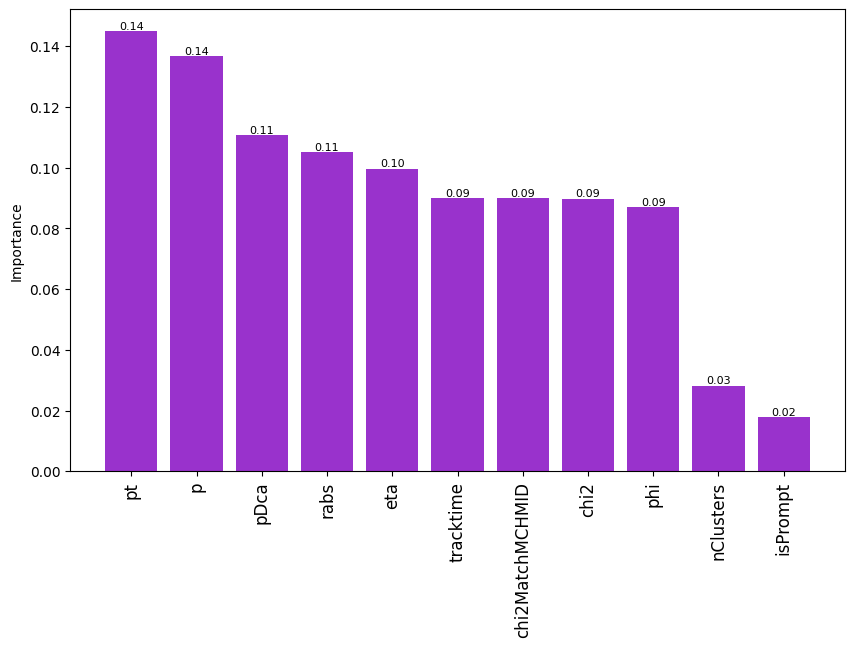

In [25]:
importances = random_forest.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(10,6))
bars = plt.bar(range(x_raw.shape[1]), importances[indices], linewidth=1, color='darkorchid')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f"{height:.2f}", ha="center", va="bottom", size=8)

plt.ylabel("Importance")
plt.xticks(range(x_raw.shape[1]), np.array(x_raw.columns)[indices], rotation=90, size=12)

In [26]:
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers

keras.backend.clear_session()

def make_mlp(input_dim, hidden=[90, 80, 60, 55, 35], drop=0.3, l2=0):
    """
    Build a binary-classification MLP.

    Args:
        input_dim (int): number of input features (columns) after preprocessing.
        hidden (list[int]): how many neurons (units) to put in each hidden layer.
                            Example [256,128,64] means 3 hidden layers with those widths.
        drop (float): dropout rate (0.0–0.5 typical). Dropout randomly turns off a
                      fraction of neurons during training to reduce overfitting.
        l2 (float): L2 weight regularization strength (a small penalty on large weights).
                    Helps keep the model simpler and more generalizable.

    Returns:
        keras.Model: a compiled model ready to train with model.fit(...)
    """

    # ----- 1) Define the input “place holder” -----
    # Shape=(input_dim,) means the model expects a 1D vector of length input_dim for each row.
    inputs = keras.Input(shape=(input_dim,), name="features")

    # We'll wire layers onto this tensor "x". We start with x=inputs.
    x = inputs

    # ----- 2) Hidden layers (the actual “learning” happens here) -----
    # We loop over the list "hidden" so it’s easy to change depth/width from the function call.
    for i, h in enumerate(hidden, start=1):
        # Dense = fully connected layer. 'h' controls how many neurons (capacity).
        # activation='relu' is a standard nonlinearity that helps the network learn complex patterns.
        # kernel_regularizer adds the L2 penalty (weight decay) to fight overfitting.
        x = layers.Dense(
            h,
            activation="relu",
            kernel_regularizer=regularizers.l2(l2),
            name=f"dense_{i}"
        )(x)

        # Batch Normalization stabilizes and speeds up training by normalizing activations
        # inside the network (per mini-batch). This often allows slightly higher learning rates.
        x = layers.BatchNormalization(name=f"bn_{i}")(x)

        # Dropout randomly zeroes out a fraction `drop` of activations during training.
        # Think of it as creating slightly different sub-networks each step, which prevents
        # the model from relying too heavily on any single path (“co-adaptation”).
        x = layers.Dropout(drop, name=f"drop_{i}")(x)

    # ----- 3) Output layer -----
    # We have a **binary** classification problem (signal vs background),
    # so we produce ONE number in [0,1] using 'sigmoid'.
    # This can be interpreted as P(y=1 | x) = probability of signal.
    outputs = layers.Dense(1, activation="sigmoid", name="logit")(x)

    # ----- 4) Build the model graph -----
    model = keras.Model(inputs, outputs, name="mlp_higgs")

    # ----- 5) Choose optimizer, loss, and metrics -----
    # Optimizer: Adam is a good default that adapts the learning rate during training.
    # Loss: binary cross-entropy is the standard for binary classification.
    # Metrics:
    #   - AUC (ROC-AUC): threshold-free measure of ranking quality.
    #   - Precision & Recall: computed at a default threshold (0.5) — useful but threshold-dependent.
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.AUC(name="auc"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
        ],
    )

    return model

# ----- 6) Create the model -----
# X_train.shape[1] is “how many feature columns do we have?”
# We use 3 hidden layers with widths 256 → 128 → 64, 20% dropout, tiny L2 penalty.
mlp = make_mlp(
    input_dim=x_train.shape[1],
    hidden=[90, 80, 60, 55, 35],
    drop=0.3,
    l2=0
)
#[90, 80, 60, 50, 25]
# Show a summary table of the layers, shapes, and parameter counts.
mlp.summary()

Model: "mlp_higgs"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ features (InputLayer)           │ (None, 11)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 90)             │         1,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 90)             │           360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 90)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 80)             │         7,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 80)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 80)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 60)             │         4,860 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 60)             │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_3 (Dropout)                │ (None, 60)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 55)             │         3,355 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_4 (BatchNormalization)       │ (None, 55)             │           220 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_4 (Dropout)                │ (None, 55)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 35)             │         1,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_5 (BatchNormalization)       │ (None, 35)             │           140 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_5 (Dropout)                │ (None, 35)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logit (Dense)                   │ (None, 1)              │            36 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,851 (77.54 KB)

 Trainable params: 19,211 (75.04 KB)

 Non-trainable params: 640 (2.50 KB)

In [27]:
history = mlp.fit(
    x_train, y_train,
    sample_weight=w_train,              # <-- important: use sample weights
    validation_data=(x_test, y_test, w_test),
    epochs=30,
    batch_size=80,
    verbose=1
)

Epoch 1/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - auc: 0.5200 - loss: 0.8908 - precision: 0.3577 - recall: 0.5084 - val_auc: 0.6989 - val_loss: 0.6608 - val_precision: 0.4822 - val_recall: 0.6239
Epoch 2/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - auc: 0.6342 - loss: 0.7122 - precision: 0.4322 - recall: 0.6014 - val_auc: 0.7177 - val_loss: 0.6327 - val_precision: 0.5148 - val_recall: 0.6530
Epoch 3/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - auc: 0.6585 - loss: 0.6791 - precision: 0.4459 - recall: 0.6064 - val_auc: 0.7265 - val_loss: 0.6165 - val_precision: 0.4914 - val_recall: 0.7368
Epoch 4/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - auc: 0.6650 - loss: 0.6698 - precision: 0.4596 - recall: 0.6348 - val_auc: 0.7345 - val_loss: 0.6091 - val_precision: 0.5343 - val_recall: 0.6530
Epoch 5/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - auc: 0.6917 - loss: 0.6499 - precision: 0.4885 - recall: 0.6282 - val_auc: 0.7405 - val_loss: 0.6032 - val_precision: 0.5234 - val_recall: 0.6872
Epoch 6

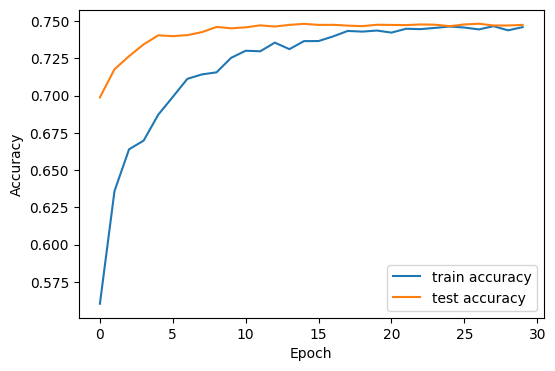

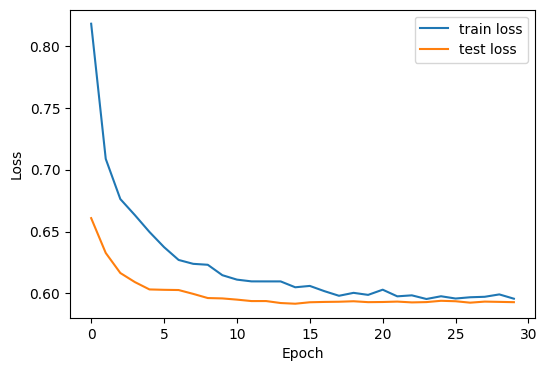

In [28]:
h = history.history
plt.figure(figsize=(6,4))
plt.plot(h['auc'], label='train accuracy')
plt.plot(h['val_auc'], label='test accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.show()

plt.figure(figsize=(6,4))
plt.plot(h['loss'], label='train loss')
plt.plot(h['val_loss'], label='test loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.show()

In [29]:
#WITH WEIGHTS

In [30]:
from sklearn.metrics import roc_curve, precision_recall_curve, accuracy_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.metrics import precision_score, recall_score

proba_test_nn = mlp.predict(x_test, batch_size=80).ravel()
pred_test_nn_05 = (proba_test_nn >= 0.5).astype(int)


metrics_nn_weighted = {
    "Accuracy": accuracy_score(y_test, pred_test_nn_05, sample_weight= w_test),
    "F1": f1_score(y_test, pred_test_nn_05, sample_weight=w_test),
    "ROC_AUC": roc_auc_score(y_test, proba_test_nn, sample_weight=w_test),
    "ConfusionMatrix": confusion_matrix(y_test, pred_test_nn_05, sample_weight=w_test)
}
metrics_nn_weighted

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


{'Accuracy': 0.6779782443600069,
 'F1': 0.6868242400244319,
 'ROC_AUC': np.float64(0.7477128766098664),
 'ConfusionMatrix': array([[546.4816773 , 294.3183227 ],
        [247.37872049, 593.99657886]])}

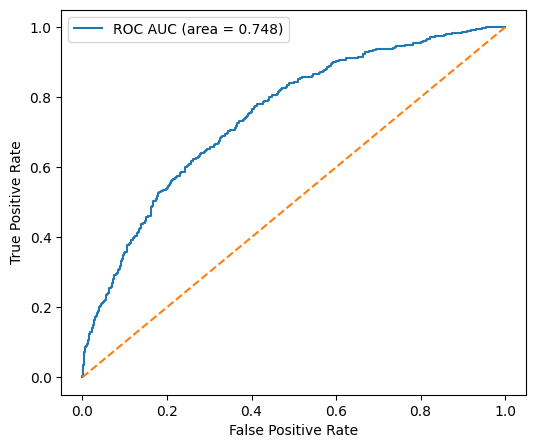

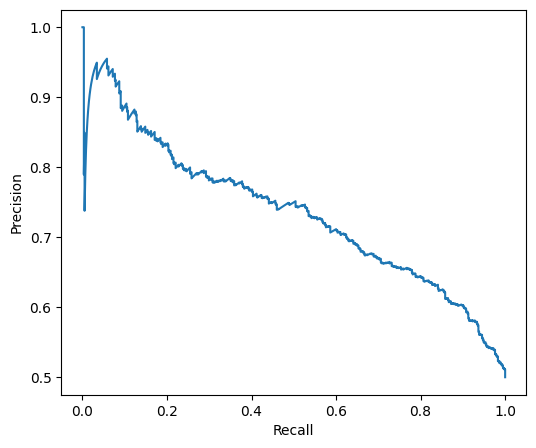

Weighted confusion matrix (threshold=0.5):
 [[546.4816773  294.3183227 ]
 [247.37872049 593.99657886]]


In [31]:
# ROC
fpr, tpr, thresholds = roc_curve(y_test, proba_test_nn, sample_weight= w_test)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC AUC (area = {roc_auc_score(y_test, proba_test_nn, sample_weight= w_test):.3f})")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.legend(); plt.show()

# PR
prec, rec, thr = precision_recall_curve(y_test, proba_test_nn, sample_weight= w_test)
plt.figure(figsize=(6,5))
plt.plot(rec, prec)
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.show()

print("Weighted confusion matrix (threshold=0.5):\n", metrics_nn_weighted["ConfusionMatrix"])

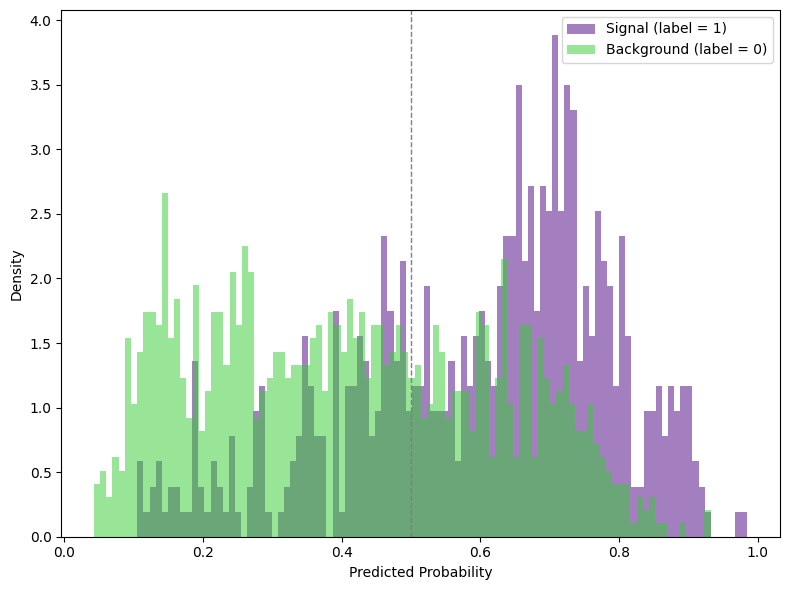

In [32]:
signal = proba_test_nn[y_test == 1]
background = proba_test_nn[y_test == 0]

plt.figure(figsize=(8,6))
bins = np.linspace(0, 1, 40)

plt.axvline(0.5, color='gray', linestyle='--', linewidth=1)

plt.hist(signal, bins=100, density=True, alpha=0.5, label='Signal (label = 1)', color='indigo')
plt.hist(background, bins=100, density=True, alpha=0.5, label='Background (label = 0)', color='limegreen')

plt.xlabel('Predicted Probability')
plt.ylabel('Density')
plt.legend()
#plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

True Negatives (TN): 546.4816773017361
False Positives (FP): 294.3183226982705
False Negatives (FN): 247.37872049264388
True Positives (TP): 593.9965788573387


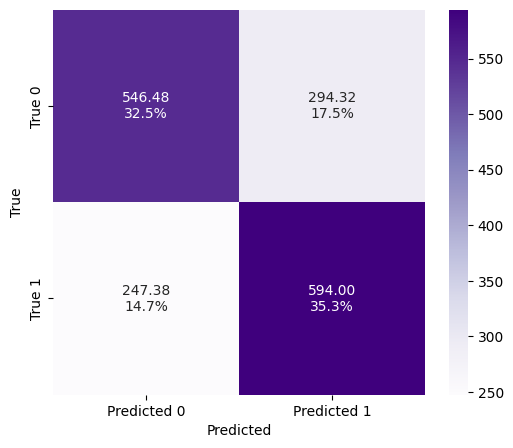

In [33]:
cmweighted = confusion_matrix(y_test, pred_test_nn_05, sample_weight=w_test)

tn, fp, fn, tp = cmweighted.ravel()

print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")


cm_percent_weight = cmweighted / cmweighted.sum()

labels = np.array([["{0:.2f}\n{1:.1%}".format(value, cm_percent_weight[i, j])
                    for j, value in enumerate(row)] for i, row in enumerate(cmweighted)])

plt.figure(figsize=(6,5))
sns.heatmap(cmweighted, annot=labels, fmt="", cmap="Purples", cbar=True,
            xticklabels=["Predicted 0","Predicted 1"],
            yticklabels=["True 0","True 1"])

plt.ylabel("True")
plt.xlabel("Predicted")
plt.show()


In [34]:
precision = precision_score(y_test, pred_test_nn_05)
recall = recall_score(y_test, pred_test_nn_05)

print(recall)
print(precision)

0.705982905982906
0.5181932245922208


In [35]:
#WITHOUT WEIGHTS

In [36]:
metrics_unweighted = {
    "Accuracy": accuracy_score(y_test, pred_test_nn_05),
    "F1": f1_score(y_test, pred_test_nn_05),
    "ROC_AUC": roc_auc_score(y_test, proba_test_nn),
    "ConfusionMatrix": confusion_matrix(y_test, pred_test_nn_05)
}
metrics_unweighted

{'Accuracy': 0.6694411414982164,
 'F1': 0.597684515195369,
 'ROC_AUC': np.float64(0.7477128766098684),
 'ConfusionMatrix': array([[713, 384],
        [172, 413]])}

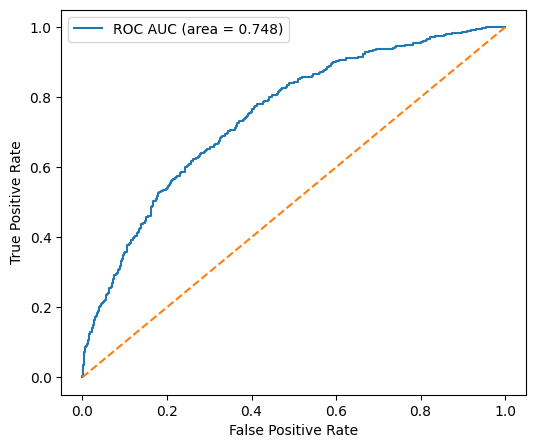

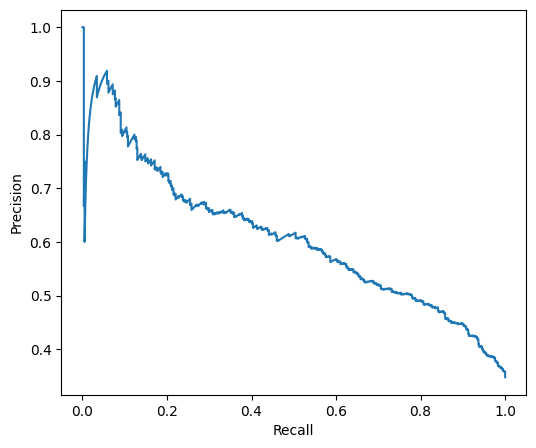

Unweighted confusion matrix (threshold=0.5):
 [[713 384]
 [172 413]]


In [37]:
# ROC
fpr, tpr, thresholds = roc_curve(y_test, proba_test_nn)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC AUC (area = {roc_auc_score(y_test, proba_test_nn):.3f})")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.legend(); plt.show()

# PR
prec, rec, thr = precision_recall_curve(y_test, proba_test_nn)
plt.figure(figsize=(6,5))
plt.plot(rec, prec)
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.show()

print("Unweighted confusion matrix (threshold=0.5):\n", metrics_unweighted["ConfusionMatrix"])

True Negatives (TN): 713
False Positives (FP): 384
False Negatives (FN): 172
True Positives (TP): 413


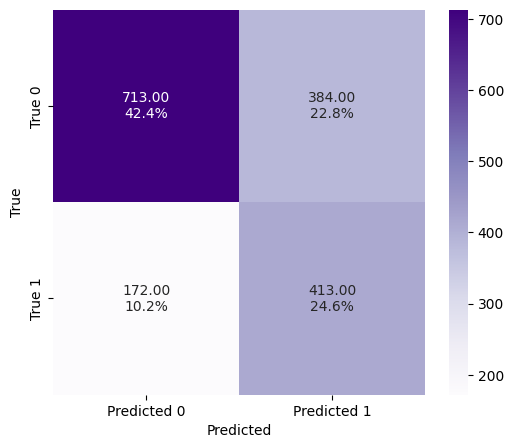

In [38]:
cm = confusion_matrix(y_test, pred_test_nn_05)

tn, fp, fn, tp = cm.ravel()

print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")


cm_percent = cm / cm.sum()

labels = np.array([["{0:.2f}\n{1:.1%}".format(value, cm_percent[i, j])
                    for j, value in enumerate(row)] for i, row in enumerate(cm)])

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=labels, fmt="", cmap="Purples", cbar=True,
            xticklabels=["Predicted 0","Predicted 1"],
            yticklabels=["True 0","True 1"])


plt.ylabel("True")
plt.xlabel("Predicted")
plt.show()
